In [ ]:
question a) and b)

In [3]:
# Data preparation for plotting
lambda_values = [300, 325, 350, 375, 400, 425]
response_time_video = []
response_time_data = []

In [4]:
for lam in lambda_values:
    Tv, Td = calculate_response_times(lam)
    # Convert to milliseconds (ms) for a better-looking plot
    response_time_video.append(Tv * 1000)
    response_time_data.append(Td * 1000)

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_43549/3783119253.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Arrival Rate per Flow, $\lambda$ (packets/s)')


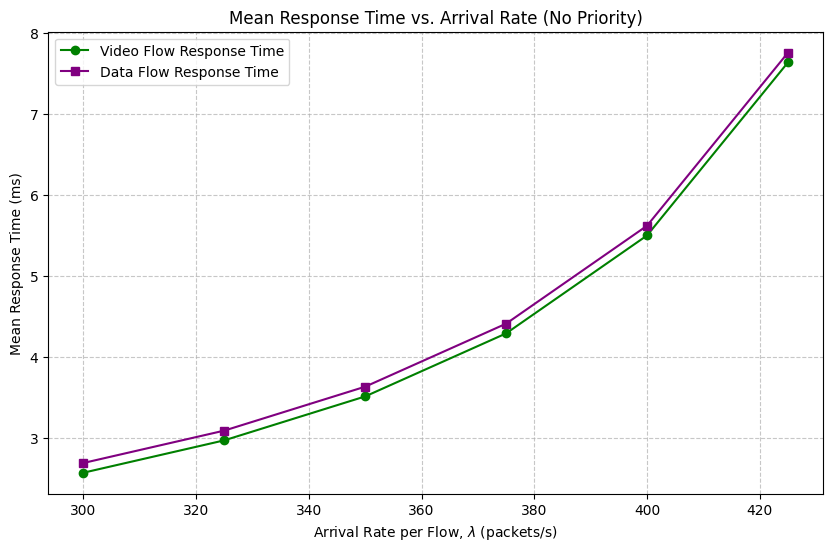

In [5]:
# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, response_time_video, marker='o', linestyle='-', color='green', label='Video Flow Response Time')
plt.plot(lambda_values, response_time_data, marker='s', linestyle='-', color='purple', label='Data Flow Response Time')

plt.title('Mean Response Time vs. Arrival Rate (No Priority)')
plt.xlabel('Arrival Rate per Flow, $\lambda$ (packets/s)')
plt.ylabel('Mean Response Time (ms)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

As the arrival rate $\lambda$ increases from 300 to 425 packets/s, the mean response times for both video and data flows rise significantly. The curves exhibit an exponential-like growth trend as the total traffic load $\rho$ approaches the link capacity.
Notice that the curves for video and data are completely parallel. The only difference is a small constant offset, which exactly equals the difference in their inherent transmission times (since data packets are slightly larger at 135 bytes vs. 120 bytes). In this FIFO (First-In-First-Out) model, both flows suffer from the exact same queuing delay, regardless of their urgency.

question e) and f)

\subsection*{Partial Buffer Sharing (PBS) Loss Probabilities (Question e)}

We model the finite buffer as an M/M/1/K queue with state-dependent arrival rates. 
Let $\lambda_v = 400$ packets/s and $\lambda_d = 400$ packets/s be the arrival rates for video and data flows, respectively. 
Since both packet sizes are fixed at 120 bytes, the service rate $\mu$ for a 1 Mbps link is identical for both flows:
\[
\mu = \frac{1 \times 10^6 \text{ bits/s}}{120 \times 8 \text{ bits/packet}} \approx 1041.67 \text{ packets/s}
\]

Let $P_k$ denote the steady-state probability of having $k$ packets in the buffer. The balance equations for the Birth-Death process are defined by the varying arrival rates:
\begin{itemize}
    \item For $1 \le k \le B_1$ (both flows admitted):
    \[
    P_k = \left( \frac{\lambda_v + \lambda_d}{\mu} \right)^k P_0
    \]
    
    \item For $B_1 < k \le B_2$ (only data flow admitted):
    \[
    P_k = \left( \frac{\lambda_d}{\mu} \right)^{k - B_1} P_{B_1}
    \]
\end{itemize}

The probability $P_0$ is found using the normalization condition, where the sum of all state probabilities must equal 1:
\[
\sum_{k=0}^{B_2} P_k = 1
\]

Based on this steady-state distribution, we can define the loss probabilities for each flow:
\begin{itemize}
    \item \textbf{Video Loss Probability:} Video packets are rejected as soon as the buffer occupancy reaches or exceeds the threshold $B_1$.
    \[
    P_{\text{loss}, v} = \sum_{k=B_1}^{B_2} P_k
    \]
    
    \item \textbf{Data Loss Probability:} Data packets are only rejected when the entire buffer capacity $B_2$ is strictly full.
    \[
    P_{\text{loss}, d} = P_{B_2}
    \]
\end{itemize}

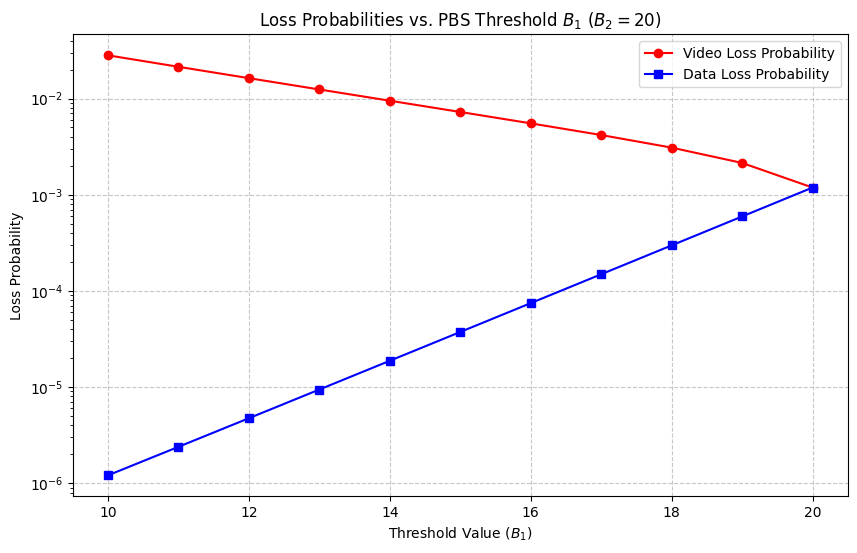

In [1]:
import matplotlib.pyplot as plt

def calculate_pbs_loss(B1, B2=20):
    """
    Calculate the loss probabilities for video and data flows under PBS.
    B1: Threshold for rejecting video packets
    B2: Total buffer size (fixed at 20)
    """
    lambda_v = 400  # Video arrival rate
    lambda_d = 400  # Data arrival rate
    capacity_bps = 1_000_000
    
    # Calculate service rate mu (packets/s)
    packet_size_bits = 120 * 8
    mu = capacity_bps / packet_size_bits
    
    # 1. Calculate unnormalized steady-state probabilities
    terms = [0] * (B2 + 1)
    terms[0] = 1.0  # Base state P0
    
    for k in range(1, B2 + 1):
        if k <= B1:
            # Below threshold: accept both flows
            terms[k] = terms[k-1] * ((lambda_v + lambda_d) / mu)
        else:
            # Above threshold: accept ONLY data flows
            terms[k] = terms[k-1] * (lambda_d / mu)
            
    # 2. Normalize probabilities
    sum_terms = sum(terms)
    P = [t / sum_terms for t in terms]
    
    # 3. Calculate Loss Probabilities
    # Video is lost when buffer >= B1
    P_loss_video = sum(P[B1 : B2 + 1])
    
    # Data is lost only when buffer is completely full (state B2)
    P_loss_data = P[B2]
    
    return P_loss_video, P_loss_data

# Prepare data: B1 varies from B2/2 (10) up to B2 (20)
B2_max = 20
B1_values = list(range(10, B2_max + 1))
loss_prob_video = []
loss_prob_data = []

for b1 in B1_values:
    pv, pd = calculate_pbs_loss(b1, B2_max)
    loss_prob_video.append(pv)
    loss_prob_data.append(pd)

# Plot the graph for question (f)
plt.figure(figsize=(10, 6))
plt.plot(B1_values, loss_prob_video, marker='o', linestyle='-', color='red', label='Video Loss Probability')
plt.plot(B1_values, loss_prob_data, marker='s', linestyle='-', color='blue', label='Data Loss Probability')

plt.title('Loss Probabilities vs. PBS Threshold $B_1$ ($B_2 = 20$)')
plt.xlabel('Threshold Value ($B_1$)')
plt.ylabel('Loss Probability')
plt.yscale('log')  # Log scale highlights the performance differences
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

When $B_1$ is low (e.g., $B_1 = 10$), half of the buffer is exclusively reserved for data packets. Consequently, the data loss probability (blue curve) is minimized, ensuring high reliability for data flows. 

However, this comes at a significant penalty to the video flow, which experiences an extremely high loss probability (red curve) because video packets are rejected very early.

As $B_1$ increases and approaches $B_2$, the buffer becomes more equally shared. The video loss probability improves (decreases), but the data loss probability degrades (increases) drastically.

When $B_1 = 20$, the threshold equals the maximum buffer size. The admission control is effectively removed, turning the system into a standard Drop-Tail queue where both flows suffer the exact same high probability of packet loss.

Conclusion: Setting an appropriate $B_1$ (such as 15 or 16) provides an excellent compromise, ensuring near-zero loss for critical data while maintaining an acceptable loss rate for video flows.